In [10]:
import pandas as pd

df = pd.read_csv("full_dataset.csv")

Exploratory Data Analysis

In [11]:
df.head()

,cpg_density,genomic_location,regulatory_score,conservation_score,methylation_status
0,0.799343,0.949839,0.297447,0.268438,1
1,0.672347,0.831158,0.456644,0.477923,1
2,0.829538,0.614908,0.262274,0.567279,0
3,1.000000,0.438266,0.407612,1.000000,1
4,0.653169,0.774556,0.000000,0.761311,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cpg_density         1000 non-null   float64
 1   genomic_location    1000 non-null   float64
 2   regulatory_score    1000 non-null   float64
 3   conservation_score  1000 non-null   float64
 4   methylation_status  1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [13]:
df.describe()

,cpg_density,genomic_location,regulatory_score,conservation_score,methylation_status
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.697508,0.611986,0.501159,0.643147,0.554000
std,0.183028,0.234104,0.270085,0.198944,0.497324
min,0.051747,0.000000,0.000000,0.064110,0.000000
25%,0.570482,0.448440,0.305600,0.502516,0.000000
50%,0.705060,0.615769,0.499925,0.650037,1.000000
75%,0.829589,0.782221,0.698275,0.783389,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df["methylation_status"].value_counts()

,count
methylation_status,
1,554
0,446


Data splitting


In [15]:
import pandas as pd

train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")


In [16]:
X_train = train.drop("methylation_status", axis=1)
y_train = train["methylation_status"]

X_test = test.drop("methylation_status", axis=1)
y_test = test["methylation_status"]


**I_Logitic** **Regression**

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [18]:
y_pred = model.predict(X_test)


Model Evaluation

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.975


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.96      0.97        89
           1       0.96      0.99      0.98       111

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



The model performed very well so we should make sure it learned meaningful patterns !!


Model performance investigations

1__Confusion Matrix


In [21]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 85,   4],
       [  1, 110]])

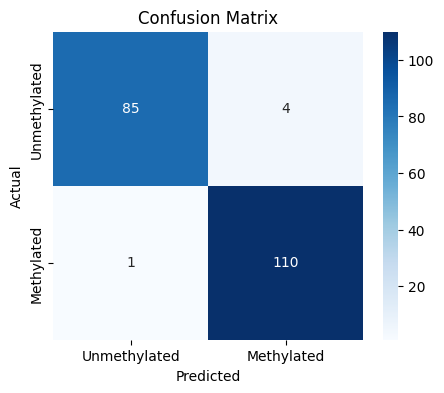

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unmethylated", "Methylated"],
    yticklabels=["Unmethylated", "Methylated"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

2__Feature exploration


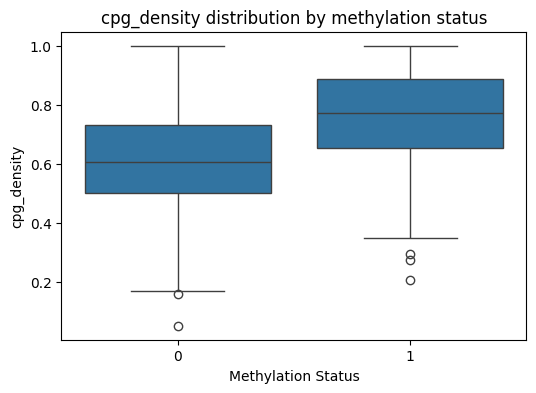

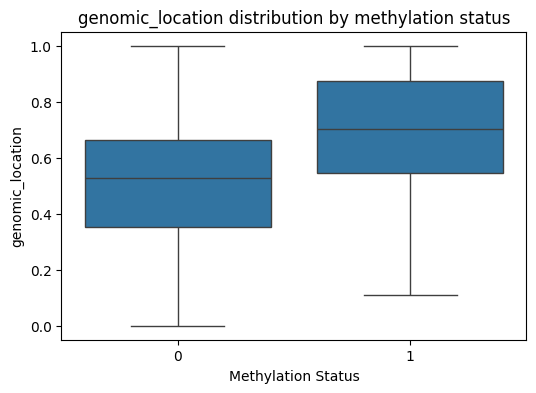

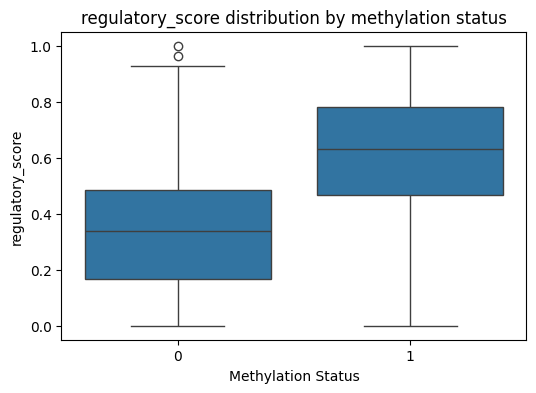

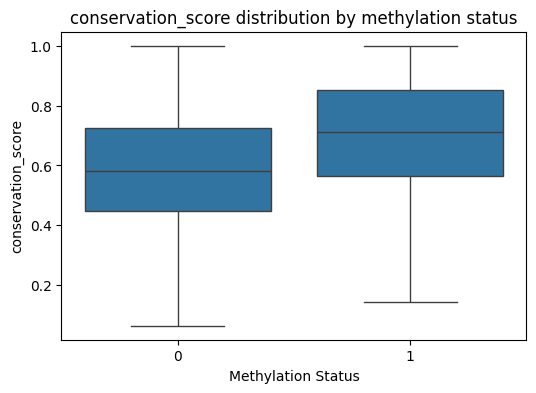

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "cpg_density",
    "genomic_location",
    "regulatory_score",
    "conservation_score"
]

for feature in features:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=train,
        x="methylation_status",
        y=feature
    )

    plt.title(f"{feature} distribution by methylation status")
    plt.xlabel("Methylation Status")
    plt.ylabel(feature)

    plt.show()



3___Correlation analysis

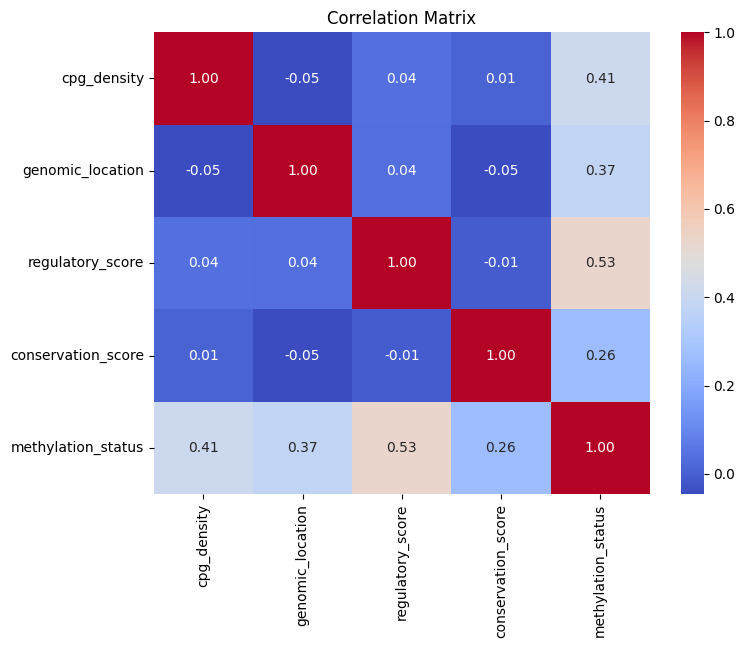

In [24]:

corr_matrix = train.corr()

corr_matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


In [25]:
target_corr = corr_matrix["methylation_status"].sort_values(ascending=False)

target_corr


,methylation_status
methylation_status,1.000000
regulatory_score,0.526496
cpg_density,0.409421
genomic_location,0.374652
conservation_score,0.261519


4__feature importance

In [26]:

model.coef_
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

feature_importance

,Feature,Coefficient
0,cpg_density,6.712933
1,genomic_location,5.581972
2,regulatory_score,6.327850
3,conservation_score,4.393845


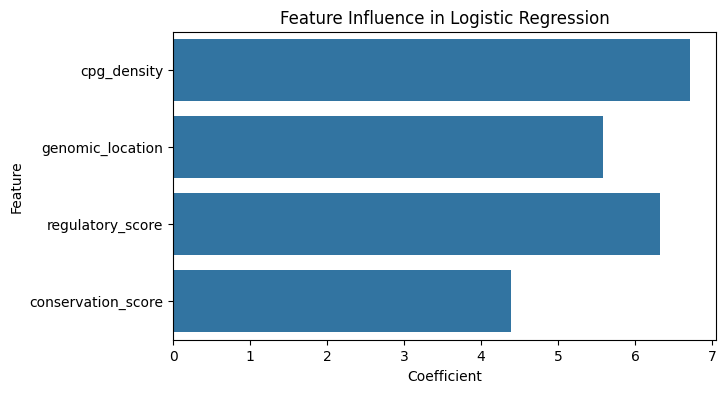

In [27]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Influence in Logistic Regression")
plt.show()

5__Investigating the model confidence

In [51]:
y_prob = model.predict_proba(X_test)
methylation_prob = y_prob[:,1]

methylation_prob[:10]

array([0.98718458, 0.76515772, 0.94628819, 0.77747551, 0.10939788,
       0.39887874, 0.93788058, 0.79003123, 0.40942732, 0.20040543])

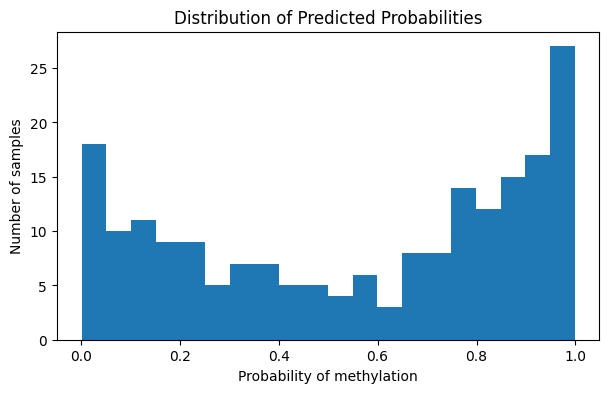

In [52]:
plt.figure(figsize=(7,4))

plt.hist(
    methylation_prob,
    bins=20
)

plt.xlabel("Probability of methylation")
plt.ylabel("Number of samples")
plt.title("Distribution of Predicted Probabilities")

plt.show()

**II_Decision** **Tree**

In [31]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

Model Evaluation

In [32]:
from sklearn.metrics import accuracy_score

accuracy_tree = accuracy_score(y_test, y_pred_tree)

accuracy_tree

0.87

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        89
           1       0.88      0.89      0.88       111

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200



1__Confusion matrix

In [34]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

cm_tree

array([[75, 14],
       [12, 99]])

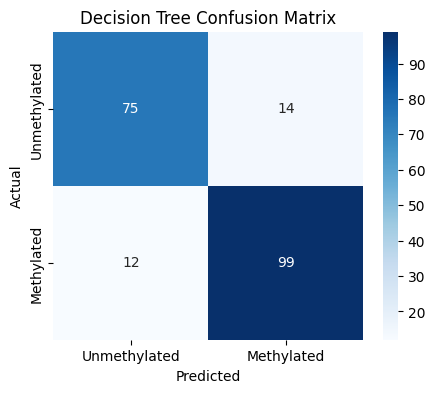

In [35]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unmethylated", "Methylated"],
    yticklabels=["Unmethylated", "Methylated"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

2__depth of the decision tree

In [36]:
tree_model.get_depth()
tree_model.get_n_leaves()

np.int64(71)

3__check for overfitting

In [37]:
train_pred_tree = tree_model.predict(X_train)

train_accuracy_tree = accuracy_score(y_train, train_pred_tree)

print(f"Training Accuracy of the unpruned tree: {train_accuracy_tree}.")


Training Accuracy of the unpruned tree: 1.0.


4__training a decision tree with less depth

In [38]:
tree_model_pruned = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
tree_model_pruned.fit(X_train, y_train)
y_pred_tree_pruned = tree_model_pruned.predict(X_test)
train_pred_tree_pruned = tree_model_pruned.predict(X_train)

train_accuracy_tree_pruned = accuracy_score(
    y_train,
    train_pred_tree_pruned
)

train_accuracy_tree_pruned

0.93125

In [39]:
test_accuracy_tree_pruned = accuracy_score(
    y_test,
    y_pred_tree_pruned
)

test_accuracy_tree_pruned

0.83

5__testing different tree depths

In [41]:
depths = [3, 5, 10, 15, 20, 30]
train_accuracies = []
test_accuracies = []
for depth in depths:

    tree_model_temp = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree_model_temp.fit(X_train, y_train)

    train_pred = tree_model_temp.predict(X_train)
    test_pred = tree_model_temp.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

depth_results = pd.DataFrame({
    "Depth": depths,
    "Training Accuracy": train_accuracies,
    "Testing Accuracy": test_accuracies
})

depth_results

,Depth,Training Accuracy,Testing Accuracy
0,3,0.85250,0.76
1,5,0.93125,0.83
2,10,0.99875,0.89
3,15,1.00000,0.87
4,20,1.00000,0.87
5,30,1.00000,0.87


**III_Random** **Forest**

In [42]:
from sklearn.ensemble import RandomForestClassifier
forest_model = RandomForestClassifier(
    random_state=42
)
forest_model.fit(X_train, y_train)
y_pred_forest = forest_model.predict(X_test)
accuracy_forest = accuracy_score(y_test, y_pred_forest)

accuracy_forest

0.95

Model evaluation


In [43]:
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        89
           1       0.95      0.96      0.96       111

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



1__confusion matrix

In [44]:
cm_forest = confusion_matrix(y_test, y_pred_forest)

cm_forest

array([[ 83,   6],
       [  4, 107]])

2__Feature importance

In [45]:
feature_importance = forest_model.feature_importances_

feature_importance
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

feature_importance_df


,Feature,Importance
0,cpg_density,0.260672
1,genomic_location,0.239823
2,regulatory_score,0.355230
3,conservation_score,0.144275


In [53]:
y_pred_forest_train = forest_model.predict(X_train)
accuracy_forest_train = accuracy_score(
    y_train,
    y_pred_forest_train
)

accuracy_forest_train

1.0

| Model               | Test accuracy | Interpretation                                                   |
| ------------------- | ------------: | ---------------------------------------------------------------- |
| Logistic Regression |           97% | Best performance; data follows a relatively simple pattern       |
| Random Forest       |           95% | Strong model; captures complex patterns with limited overfitting |
| Decision Tree       |           87% | Overfits due to high complexity                                  |
